In [34]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

#### Load Dataset

In [35]:
df = pd.read_csv("data.csv")

In [36]:
print("Shape:", df.shape)

Shape: (569, 33)


In [37]:
print(df.head(5))

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [39]:
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

#### Check for Missing Values

In [40]:
print("Any Missing Values:", df.isnull().values.any())

Any Missing Values: False


#### Encode Target and Define Features

In [41]:
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # Malignant = 1, Benign = 0

X = df.drop(columns=["diagnosis"]).values
y = df["diagnosis"].values

##### Train-Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Feature Scaling

In [43]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#### Scratch KNN Regressor Implementation

In [44]:
class ScratchKNNClassifier:

  def __init__(self, k=5):
    self.k = k

  def fit(self, X, y):
    self.X_train = X
    self.y_train = y

  def _compute_distances(self, X):
    # Euclidean distance formula calculation
    return np.sqrt(
        np.sum(
            (X[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]) ** 2, axis=2
        )
    )

  def predict(self, X):
    distances = self._compute_distances(X)
    predictions = []
    for row_dist in distances:
      nearest_indices = np.argsort(row_dist)[: self.k]
      nearest_labels = self.y_train[nearest_indices]
      # Majority vote
      most_common = Counter(nearest_labels).most_common(1)
      predictions.append(most_common[0][0])
    return np.array(predictions)

  def predict_proba(self, X):
    distances = self._compute_distances(X)
    probas = []
    for row_dist in distances:
      nearest_indices = np.argsort(row_dist)[: self.k]
      nearest_labels = self.y_train[nearest_indices]
      prob_1 = np.sum(nearest_labels == 1) / self.k
      probas.append([1 - prob_1, prob_1])
    return np.array(probas)

#### Train and Predict

In [45]:
knn_clf = ScratchKNNClassifier(k=5)
knn_clf.fit(X_train, y_train)
y_pred = knn_clf.predict(X_test)

#### Calculate Evaluation Metrics

In [46]:
accuracy = np.mean(y_pred == y_test) * 100
mse = np.mean((y_test - y_pred) ** 2)
loss = log_loss(y_test, knn_clf.predict_proba(X_test))

#### Evaluation Results

In [47]:
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Log Loss: {loss:.4f}")

Test Accuracy: 94.74%
Mean Squared Error: 0.0526
Log Loss: 0.3981


#### Target Variable Distribution

C:\Users\saher\AppData\Local\Temp\ipykernel_7400\1682870738.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


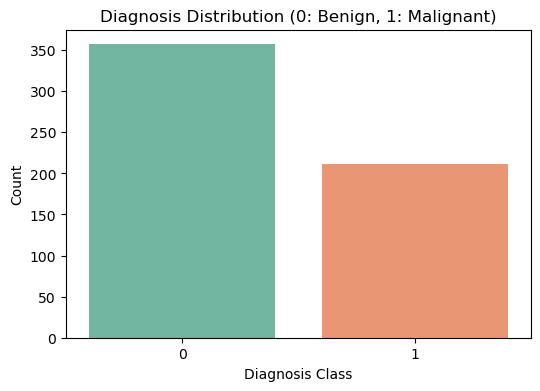

In [49]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette="Set2")
plt.title("Diagnosis Distribution (0: Benign, 1: Malignant)")
plt.xlabel("Diagnosis Class")
plt.ylabel("Count")
plt.show()

#### KNN Regressor RMSE Across Different K Values

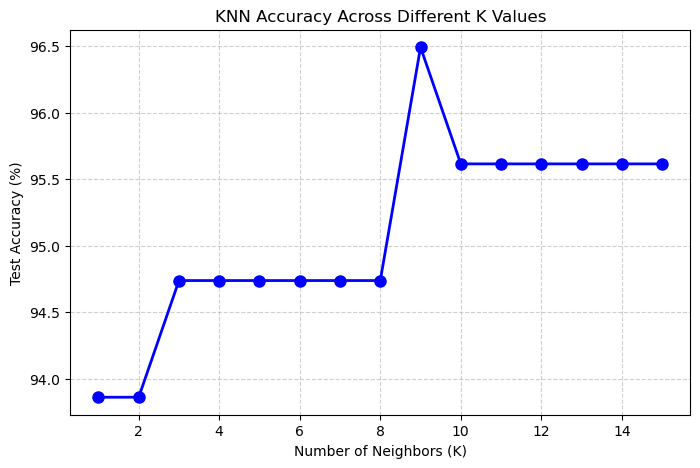

In [50]:
k_values = range(1, 16)
accuracies = []
for k in k_values:
  knn = ScratchKNNClassifier(k=k)
  knn.fit(X_train, y_train)
  y_pred_k = knn.predict(X_test)
  acc = np.mean(y_pred_k == y_test) * 100
  accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(
    k_values,
    accuracies,
    marker="o",
    linestyle="-",
    color="b",
    linewidth=2,
    markersize=8,
)
plt.title("KNN Accuracy Across Different K Values")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Test Accuracy (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

#### Feature Scatter Plot (Radius Mean vs Texture Mean)

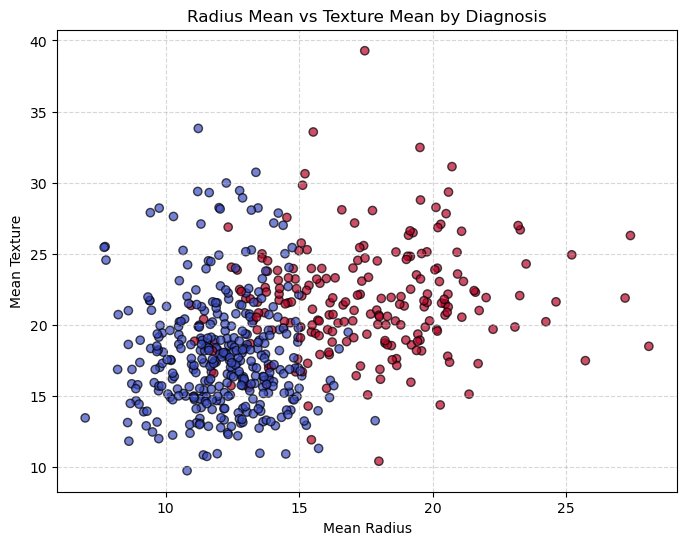

In [51]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["radius_mean"],
    df["texture_mean"],
    c=y,
    cmap="coolwarm",
    alpha=0.7,
    edgecolor="k",
)
plt.title("Radius Mean vs Texture Mean by Diagnosis")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

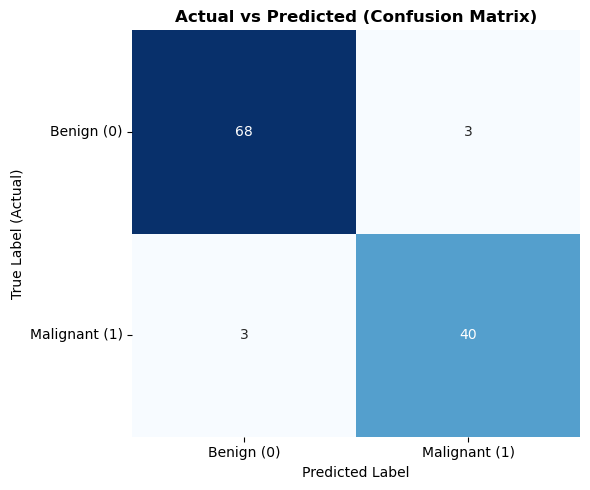

In [52]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(
    'Actual vs Predicted (Confusion Matrix)', fontsize=12, fontweight='bold'
)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label (Actual)', fontsize=10)
plt.xticks(ticks=[0.5, 1.5], labels=['Benign (0)', 'Malignant (1)'])
plt.yticks(
    ticks=[0.5, 1.5], labels=['Benign (0)', 'Malignant (1)'], rotation=0
)
plt.tight_layout()
plt.show()